In [1]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import glob
import sys

import h5py
from cosmoSim import cosmoSim
from scipy.interpolate import interp1d
from scipy.stats import binned_statistic

In [2]:
FONT_SIZE = 14

matplotlib.rc('xtick', labelsize=FONT_SIZE)
matplotlib.rc('ytick', labelsize=FONT_SIZE)
matplotlib.rcParams['font.size']=FONT_SIZE

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rc('text', usetex=True)

ALPHA=0.8

UNIT_HEIGHT = 5

FIG_HEIGHT = 2* UNIT_HEIGHT
FIG_WIDTH = 3 * UNIT_HEIGHT

FIGSIZE=[FIG_WIDTH,FIG_HEIGHT]
DPI=300

snap_ranges = [
    [5, 4, 3], 
    [2, 1, 0]
]

zz_color = 'b'
m2m2_color = 'g'
cdm_color = 'r'
zz_dm_color = 'tab:cyan'
m2m2_dm_color = 'tab:olive'
cdm_dm_color = 'tab:pink'

In [3]:
outpath = '../plots/plots_L3N256/grid/'
base_path="/home/ryan/projects/Medvedev/data_product_generation/data_products/data_prods/"
data_dir = '/home/ryan/Data'
try:
    os.mkdir(outpath)
except:
    print(f'{outpath} already exists!')


# CDM_runs = ['run_CDM_L3N256_HY']

# CDM_DM_runs = [ f'run_CDM_L3N256_DM_dir_{i}' for i in range(10) ] + ['run_CDM_L3N256_DM']

# tcDM_runs1 = [ f'run_2cDM_L3N256_HY_power00_sigma1_dir_{i}' for i in range(10) ] + ['run_2cDM_L3N256_HY_power00_sigma1']

# tcDM_DM_runs1 = [ f'run_2cDM_L3N256_DM_power00_sigma1_dir_{i}' for i in range(10) ] + ['run_2cDM_L3N256_DM_power00_sigma1']

#tcDM_runs2 = ['run_2cDM_L3N256_HY_powerm2m2_sigma1']

#tcDM_DM_runs2 = [ f'run_2cDM_L3N256_DM_powerm2m2_sigma1_dir_{i}' for i in range(10) ]


CDM_runs = [ f'run_CDM_L3N256_HY_dir_{i}' for i in range(10) ] + ['run_CDM_L3N256_HY']

#CDM_DM_runs = [ f'run_CDM_L3N256_DM_dir_{i}' for i in range(10) ] + ['run_CDM_L3N256_DM']

tcDM_runs1 = [ f'run_2cDM_L3N256_HY_power00_sigma1_dir_{i}' for i in range(10) ] + ['run_2cDM_L3N256_HY_power00_sigma1']

#tcDM_DM_runs1 = [ f'run_2cDM_L3N256_DM_power00_sigma1_dir_{i}' for i in range(10) ] + ['run_2cDM_L3N256_DM_power00_sigma1']

tcDM_runs2 = [ f'run_2cDM_L3N256_HY_powerm2m2_sigma1_dir_{i}' for i in range(10) ] + ['run_2cDM_L3N256_HY_powerm2m2_sigma1']

#tcDM_DM_runs2 = [ f'run_2cDM_L3N256_DM_powerm2m2_sigma1_dir_{i}' for i in range(10) ]

../plots/plots_L3N256/grid/ already exists!


In [ ]:
def read_sSFR_mass(f):
    hmass = f['Subhalo/SubhaloMassType'][()][:,4] * 10**10
    nonzero = hmass[ hmass != 0 ]
    SFR = f['Subhalo/SubhaloSFRinRad'][()][ hmass != 0 ]

    sSFR = SFR/nonzero

    return nonzero, sSFR

def get_sSFR_mass_stats(run_list, redshift):
    hmasses = np.array([])
    sSFRs = np.array([])
    for run_n in run_list:
        run = cosmoSim(run_n, base_path=base_path)
        idx = run.redshift_to_index(redshift)

        fof = os.path.join(data_dir, run_n, f'fof_subhalo_tab_{idx:03}.hdf5')
        with h5py.File(fof, 'r') as f:
            hmass, sSFR = read_sSFR_mass(f)
        hmasses = np.append(hmasses, hmass)
        sSFRs = np.append(sSFRs, sSFR)
    
    nbins = int( (np.amax(np.log10(hmasses)) - np.amin(np.log10(hmasses))) / 0.2 )

    m_bins = np.geomspace(np.amin(hmasses), np.amax(hmasses), num=nbins)

    medians = binned_statistic(hmasses, sSFRs, statistic='median', bins=m_bins)
    tenth = binned_statistic(hmasses, sSFRs, statistic=lambda x: np.percentile(x, q=10), bins=m_bins)
    ninetieth = binned_statistic(hmasses, sSFRs, statistic=lambda x: np.percentile(x, q=90), bins=m_bins)
    
    bin_centers = (m_bins[:-1] + m_bins[1:]) / 2

    return bin_centers, medians.statistic, tenth.statistic, ninetieth.statistic

def get_sSFR_mass_stats_raw(run_list, redshift):
    hmasses = np.array([])
    sSFRs = np.array([])
    for run_n in run_list:
        run = cosmoSim(run_n, base_path=base_path)
        idx = run.redshift_to_index(redshift)

        fof = os.path.join(data_dir, run_n, f'fof_subhalo_tab_{idx:03}.hdf5')
        with h5py.File(fof, 'r') as f:
            hmass, sSFR = read_sSFR_mass(f)
        hmasses = np.append(hmasses, hmass)
        sSFRs = np.append(sSFRs, sSFR)
        
    return hmasses[sSFRs != 0], sSFRs[sSFRs != 0]


def read_SFR_mass(f):
    hmass = f['Subhalo/SubhaloMassType'][()][:,4] * 10**10
    nonzero = hmass[ hmass != 0 ]
    SFR = f['Subhalo/SubhaloSFRinRad'][()][ hmass != 0 ]

    return nonzero, SFR

def get_SFR_mass_stats_raw(run_list, redshift):
    hmasses = np.array([])
    SFRs = np.array([])
    for run_n in run_list:
        run = cosmoSim(run_n, base_path=base_path)
        idx = run.redshift_to_index(redshift)

        fof = os.path.join(data_dir, run_n, f'fof_subhalo_tab_{idx:03}.hdf5')
        with h5py.File(fof, 'r') as f:
            hmass, SFR = read_SFR_mass(f)
        hmasses = np.append(hmasses, hmass)
        SFRs = np.append(SFRs, SFR)
        
    return hmasses[SFRs != 0], SFRs[SFRs != 0]

# Algorithm Outline

1. Collect galaxies in 0.2-dex bins in stellar mass
2. Calculate median SFR in bin
3. Label "Quenched" as galaxies whose SFR falls below 1 dex from median
4. Remove Quenched, goto 1.
5. Until median SFR is stable to 1%

In [11]:
def get_quenched_fraction(run_n, redshift):    
    good_hmass, good_SFR = get_SFR_mass_stats_raw(run_n, redshift)

    # split into half dex bins
    nbins = int( (np.amax(np.log10(good_hmass)) - np.amin(np.log10(good_hmass))) / 0.2 )

    smbins = np.geomspace(np.amin(good_hmass), np.amax(good_hmass), num=nbins)

    medians = binned_statistic(good_hmass, good_SFR, statistic='median', bins=smbins)


    # filter out zero SFR, acknowledge small number of systems per bin, but can still do main sequence

    bin_membership = medians.binnumber

    is_quenched = np.empty_like(good_hmass, dtype=bool)

    converged = False
    # naive approach first, optimize later if needed
    while not converged:

        # filtering out halos
        # for each halo
        for i, mbin_index in enumerate(bin_membership):
            # check if SFR is 1 dex below the median at this mass
            this_SFR = np.log10(good_SFR[i])
            
            actual_mbin_index = mbin_index
            if mbin_index == (len(smbins) - 1):
                actual_mbin_index = len(smbins) - 2

            median_SFR_at_mass = np.log10(medians.statistic[actual_mbin_index])

            # if this difference is greater than 1, then this SFR is more than 1 dex below
            if (median_SFR_at_mass - this_SFR) > 1:
                is_quenched[i] = True

        # recalculate median

        old_medians = medians

        medians = binned_statistic(good_hmass[~is_quenched], good_SFR[~is_quenched], statistic='median', bins=smbins)

        percent_change = np.abs( (medians.statistic - old_medians.statistic) / old_medians.statistic )
        
        # remove nan from percent_change
        percent_change[np.isnan(percent_change)] = 0
        
        converged = (percent_change < 0.01).all()

    # calculate quenched fraction

    quenched_count_binned = np.zeros_like(smbins)
    total_per_bin = np.bincount(bin_membership)

    for i, mbin_index in enumerate(bin_membership):
        actual_mbin_index = mbin_index
        if mbin_index == (len(smbins) - 1):
            actual_mbin_index = len(smbins) - 2
        
        if is_quenched[i]:
            quenched_count_binned[actual_mbin_index] += 1

    quenched_fraction = quenched_count_binned / total_per_bin

    return smbins, quenched_fraction

/tmp/ipykernel_1964810/3501331932.py:64: RuntimeWarning: invalid value encountered in divide
  quenched_fraction = quenched_count_binned / total_per_bin
/tmp/ipykernel_1964810/3501331932.py:64: RuntimeWarning: divide by zero encountered in divide
  quenched_fraction = quenched_count_binned / total_per_bin


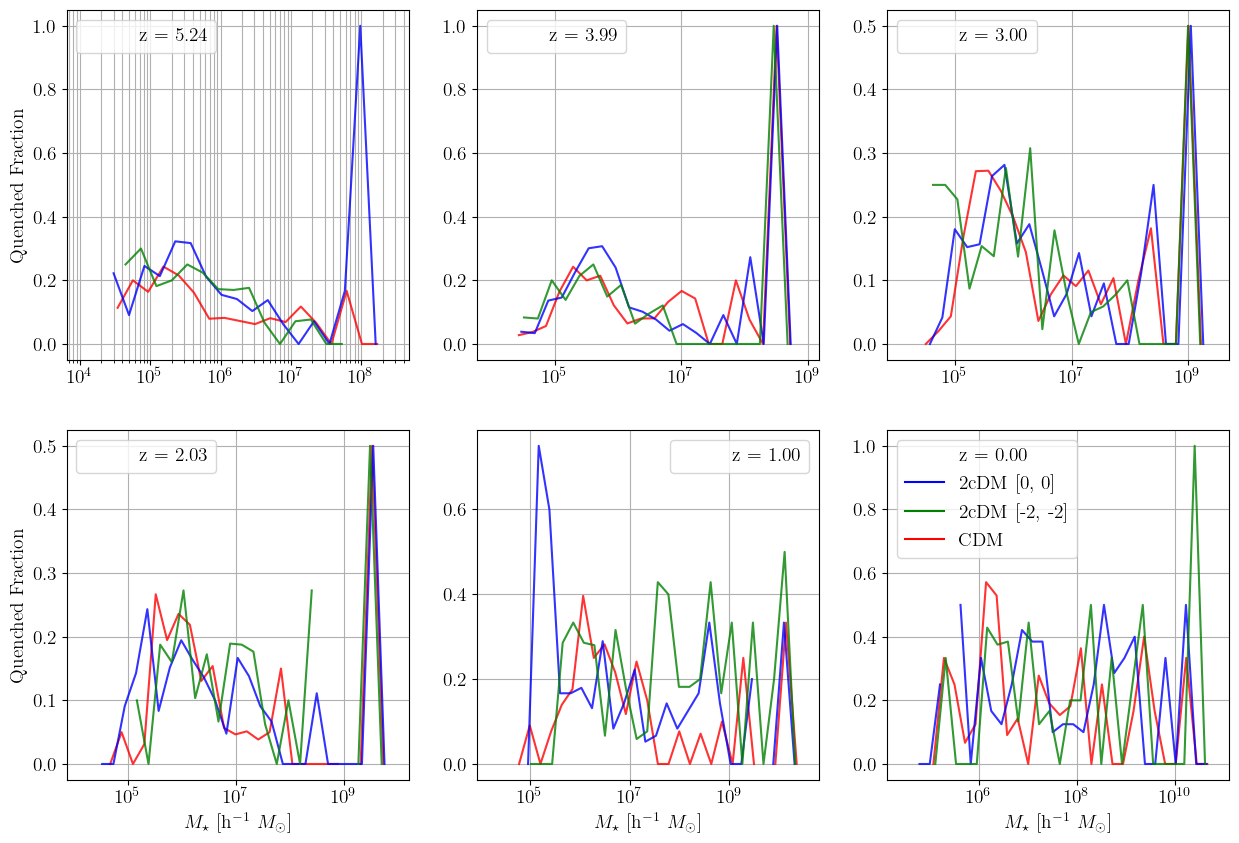

In [13]:
fig, ax = plt.subplots(2, 3, figsize=FIGSIZE)

for ar, snap_range in zip(ax, snap_ranges):
    for a, redshift in zip(ar, snap_range):

        cdm_m, cdm_f = get_quenched_fraction(CDM_runs, redshift)
        tcdm_m, tcdm_f = get_quenched_fraction(tcDM_runs1, redshift)
        twcdm_m, twcdm_f = get_quenched_fraction(tcDM_runs2, redshift)

        a.plot(cdm_m, cdm_f, alpha=ALPHA, color=cdm_color)
        a.plot(tcdm_m, tcdm_f, alpha=ALPHA, color=zz_color)
        a.plot(twcdm_m, twcdm_f, alpha=ALPHA, color=m2m2_color)


        r_nearest = cosmoSim(CDM_runs[0], base_path=base_path).get_nearest_redshift(redshift)


        a.set_xscale("log")

        xlims = [
            1/2.8 * np.amin( [cdm_m.min(), tcdm_m.min(), twcdm_m.min()] ),
            2.8 * np.amax( [cdm_m.max(), tcdm_m.max(), twcdm_m.max()] )
        ]
        a.set_xlim(xlims)
        # a.set_ylim(10**-8, 10**1)
        a.grid(True, which="both", ls="-")
        a.set_aspect( 'auto', adjustable='box' )
        a.plot([],[], label=f'z = {r_nearest:.2f}', alpha=0)
        a.legend()


for ar in ax[1, :]:
    ar.set_xlabel('$M_{\\star}$ [h$^{-1}$ $M_{\\odot}$]')

for ar in ax[:, 0]: 
    ar.set_ylabel('Quenched Fraction')

a = ax[-1,-1]
a.plot([],[], label='2cDM [0, 0]', color=zz_color)
a.plot([],[], label='2cDM [-2, -2]', color=m2m2_color)
a.plot([],[], label='CDM', color=cdm_color)

a.legend()
fname = outpath + f'grid_SFR_mass.pdf'
# plt.savefig(fname, dpi=DPI, bbox_inches='tight')
plt.show()

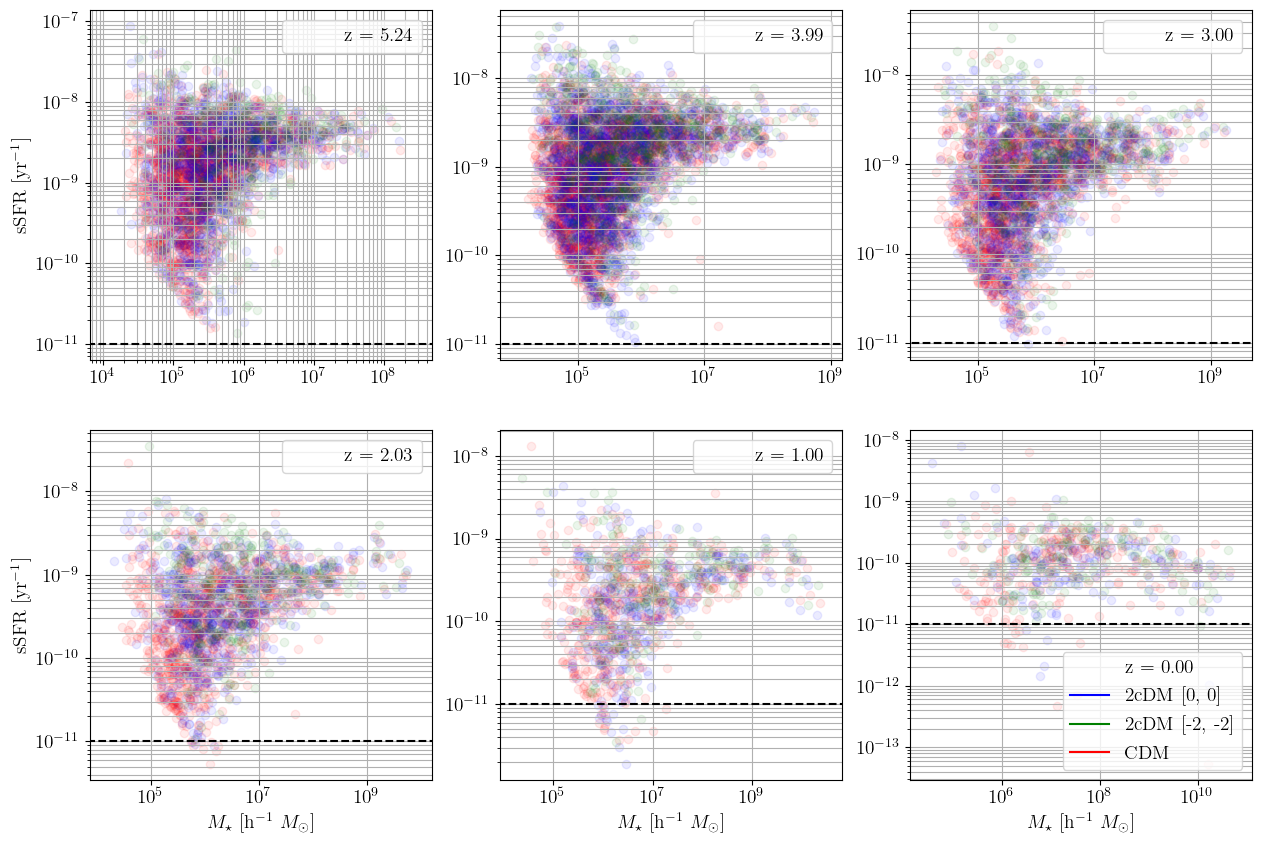

In [43]:
fig, ax = plt.subplots(2, 3, figsize=FIGSIZE)

for ar, snap_range in zip(ax, snap_ranges):
    for a, redshift in zip(ar, snap_range):

        # cdm_m, cdm_med, cdm_10, cdm_90 = get_sSFR_mass_stats(CDM_runs, redshift)

        # tcdm_m, tcdm_med, tcdm_10, tcdm_90 = get_sSFR_mass_stats(tcDM_runs1, redshift)

        # twcdm_m, twcdm_med, twcdm_10, twcdm_90 = get_sSFR_mass_stats(tcDM_runs2, redshift)

        cdm_m, cdm_med = get_sSFR_mass_stats_raw(CDM_runs, redshift)
        tcdm_m, tcdm_med = get_sSFR_mass_stats_raw(tcDM_runs1, redshift)
        twcdm_m, twcdm_med = get_sSFR_mass_stats_raw(tcDM_runs2, redshift)

        # a.plot(cdm_m, cdm_med, alpha=ALPHA, color=cdm_color)
        # a.fill_between(cdm_m, cdm_10, cdm_90, alpha=0.5*ALPHA, color=cdm_color)

        # a.plot(tcdm_m, tcdm_med, alpha=ALPHA, color=zz_color)
        # a.fill_between(tcdm_m, tcdm_10, tcdm_90, alpha=0.5*ALPHA, color=zz_color)

        # a.plot(twcdm_m, twcdm_med, alpha=ALPHA, color=m2m2_color)
        # a.fill_between(twcdm_m, twcdm_10, twcdm_90, alpha=0.5*ALPHA, color=m2m2_color)

        # a.errorbar(cdm_m, cdm_med, yerr=[cdm_10, cdm_90], fmt='o', color=cdm_color, alpha=0.5*ALPHA)

        # a.errorbar(tcdm_m, tcdm_med, yerr=[tcdm_10, tcdm_90], fmt='o', color=zz_color, alpha=0.5*ALPHA)

        # a.errorbar(twcdm_m, twcdm_med, yerr=[twcdm_10, twcdm_90], fmt='o', color=m2m2_color, alpha=0.5*ALPHA)

        a.scatter(cdm_m, cdm_med, alpha=0.1*ALPHA, color=cdm_color)
        a.scatter(tcdm_m, tcdm_med, alpha=0.1*ALPHA, color=zz_color)
        a.scatter(twcdm_m, twcdm_med, alpha=0.1*ALPHA, color=m2m2_color)


        a.hlines(10**-11, 10**1, 10**20, linestyle='dashed', color='k')

        r_nearest = cosmoSim(CDM_runs[0], base_path=base_path).get_nearest_redshift(redshift)


        a.set_yscale("log")
        a.set_xscale("log")

        xlims = [
            1/2.8 * np.amin( [cdm_m.min(), tcdm_m.min(), twcdm_m.min()] ),
            2.8 * np.amax( [cdm_m.max(), tcdm_m.max(), twcdm_m.max()] )
        ]
        a.set_xlim(xlims)
        # a.set_ylim(10**-8, 10**1)
        a.grid(True, which="both", ls="-")
        a.set_aspect( 'auto', adjustable='box' )
        a.plot([],[], label=f'z = {r_nearest:.2f}', alpha=0)
        a.legend()


for ar in ax[1, :]:
    ar.set_xlabel('$M_{\\star}$ [h$^{-1}$ $M_{\\odot}$]')

for ar in ax[:, 0]: 
    ar.set_ylabel("sSFR [yr$^{-1}$]")

a = ax[-1,-1]
a.plot([],[], label='2cDM [0, 0]', color=zz_color)
a.plot([],[], label='2cDM [-2, -2]', color=m2m2_color)
a.plot([],[], label='CDM', color=cdm_color)

a.legend()
fname = outpath + f'grid_SFR_mass.pdf'
# plt.savefig(fname, dpi=DPI, bbox_inches='tight')
plt.show()

In [48]:
def get_quenched_fraction(run_list, redshift, eps=10**-11):
    
    fracs = []

    for run_n in run_list:

        run = cosmoSim(run_n, base_path=base_path)

        idx = run.redshift_to_index(redshift)

        fof = os.path.join(data_dir, run_n, f'fof_subhalo_tab_{idx:03}.hdf5')
        
        with h5py.File(fof, 'r') as f:
            hmass = f['Subhalo/SubhaloMassType'][()][:,4] * 10**10
            nonzero = hmass[ hmass != 0 ]
            SFR = f['Subhalo/SubhaloSFRinRad'][()][ hmass != 0 ]
        
        sSFR = SFR / nonzero

        total = len(nonzero[sSFR != 0])
        quenched = (sSFR[sSFR != 0] < eps).sum()

        fracs.append(quenched / total)

    avg = np.mean(fracs)
    ten = np.percentile(fracs, 10)
    ninety = np.percentile(fracs, 90)


    return avg, ten, ninety

def get_zero_fraction(run_list, redshift):
    
    fracs = []

    for run_n in run_list:

        run = cosmoSim(run_n, base_path=base_path)

        idx = run.redshift_to_index(redshift)

        fof = os.path.join(data_dir, run_n, f'fof_subhalo_tab_{idx:03}.hdf5')
        
        with h5py.File(fof, 'r') as f:
            hmass = f['Subhalo/SubhaloMassType'][()][:,4] * 10**10
            nonzero = hmass[ hmass != 0 ]
            SFR = f['Subhalo/SubhaloSFRinRad'][()][ hmass != 0 ]
        
        sSFR = SFR / nonzero

        total = len(nonzero)
        zero = (sSFR == 0).sum()

        fracs.append(zero / total)

    avg = np.mean(fracs)
    ten = np.percentile(fracs, 10)
    ninety = np.percentile(fracs, 90)


    return avg, ten, ninety

In [49]:
def flatten(xss):
    return [x for xs in xss for x in xs]

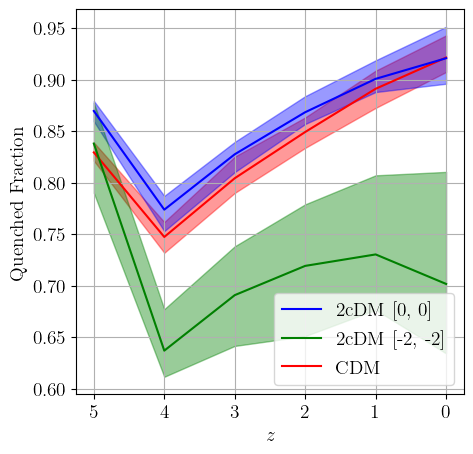

In [50]:
fig, ax = plt.subplots(1,1, figsize=[5, 5])

cdm_qfs = np.array([ get_zero_fraction(CDM_runs, redshift) for redshift in flatten(snap_ranges) ])
tcdm_qfs1 = np.array([ get_zero_fraction(tcDM_runs1, redshift) for redshift in flatten(snap_ranges) ])
tcdm_qfs2 = np.array([ get_zero_fraction(tcDM_runs2, redshift) for redshift in flatten(snap_ranges) ])

ax.plot(flatten(snap_ranges), cdm_qfs[:,0], color=cdm_color)
ax.fill_between(flatten(snap_ranges), cdm_qfs[:,1], cdm_qfs[:,2], alpha=0.5*ALPHA, color=cdm_color)
ax.plot(flatten(snap_ranges), tcdm_qfs1[:,0], color=zz_color)
ax.fill_between(flatten(snap_ranges), tcdm_qfs1[:,1], tcdm_qfs1[:,2], alpha=0.5*ALPHA, color=zz_color)
ax.plot(flatten(snap_ranges), tcdm_qfs2[:,0], color=m2m2_color)
ax.fill_between(flatten(snap_ranges), tcdm_qfs2[:,1], tcdm_qfs2[:,2], alpha=0.5*ALPHA, color=m2m2_color)

ax.grid(True, which="both", ls="-")
ax.set_aspect( 'auto', adjustable='box' )

ax.plot([],[], label='2cDM [0, 0]', color=zz_color)
ax.plot([],[], label='2cDM [-2, -2]', color=m2m2_color)
ax.plot([],[], label='CDM', color=cdm_color)

ax.set_xlabel('$z$')
ax.set_ylabel('Quenched Fraction')

ax.invert_xaxis()

ax.legend()
fname = outpath + f'quenched_fraction.pdf'
# plt.savefig(fname, dpi=DPI, bbox_inches='tight')
plt.show()

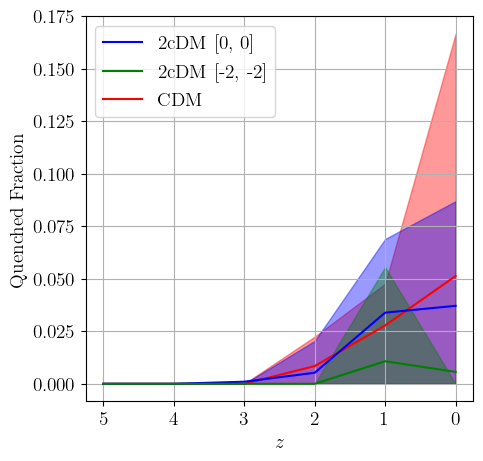

In [ ]:
fig, ax = plt.subplots(1,1, figsize=[5, 5])

cdm_qfs = np.array([ get_quenched_fraction(CDM_runs, redshift) for redshift in flatten(snap_ranges) ])
tcdm_qfs1 = np.array([ get_quenched_fraction(tcDM_runs1, redshift) for redshift in flatten(snap_ranges) ])
tcdm_qfs2 = np.array([ get_quenched_fraction(tcDM_runs2, redshift) for redshift in flatten(snap_ranges) ])

ax.plot(flatten(snap_ranges), cdm_qfs[:,0], color=cdm_color)
ax.fill_between(flatten(snap_ranges), cdm_qfs[:,1], cdm_qfs[:,2], alpha=0.5*ALPHA, color=cdm_color)
ax.plot(flatten(snap_ranges), tcdm_qfs1[:,0], color=zz_color)
ax.fill_between(flatten(snap_ranges), tcdm_qfs1[:,1], tcdm_qfs1[:,2], alpha=0.5*ALPHA, color=zz_color)
ax.plot(flatten(snap_ranges), tcdm_qfs2[:,0], color=m2m2_color)
ax.fill_between(flatten(snap_ranges), tcdm_qfs2[:,1], tcdm_qfs2[:,2], alpha=0.5*ALPHA, color=m2m2_color)

ax.grid(True, which="both", ls="-")
ax.set_aspect( 'auto', adjustable='box' )

ax.plot([],[], label='2cDM [0, 0]', color=zz_color)
ax.plot([],[], label='2cDM [-2, -2]', color=m2m2_color)
ax.plot([],[], label='CDM', color=cdm_color)

ax.set_xlabel('$z$')
ax.set_ylabel('Quenched Fraction')

ax.invert_xaxis()

ax.legend()
fname = outpath + f'quenched_fraction.pdf'
# plt.savefig(fname, dpi=DPI, bbox_inches='tight')
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3156083/1922110785.py:38: SyntaxWarning: invalid escape sequence '\o'
  ar.set_ylabel("SFR [$M_{\odot}$ yr$^{-1}$]")
/home/ryan/projects/Medvedev/dm_sims/jupyter/global/paperI/../../../py/cosmoSim.py:118: UserWarning: WARNING: Requested redshift 5 is not within tolerance 0.1 of snapshot redshift 5.236226422509304 in run run_CDM_L3N256_HY_dir_0!
  warnings.warn(f"WARNING: Requested redshift {redshift} is not within tolerance {tolerance} of snapshot redshift {self.redshifts[idx]} in run {self.run_name}!")
/home/ryan/projects/Medvedev/dm_sims/jupyter/global/paperI/../../../py/cosmoSim.py:118: UserWarning: WARNING: Requested redshift 5 is not within tolerance 0.1 of snapshot redshift 5.236226422509304 in run run_CDM_L3N256_HY_dir_1!
  warnings.warn(f"WARNING: Requested redshift {redshift} is not within tolerance {tolerance} of snapshot redshift {self.redshifts[idx]} in run {

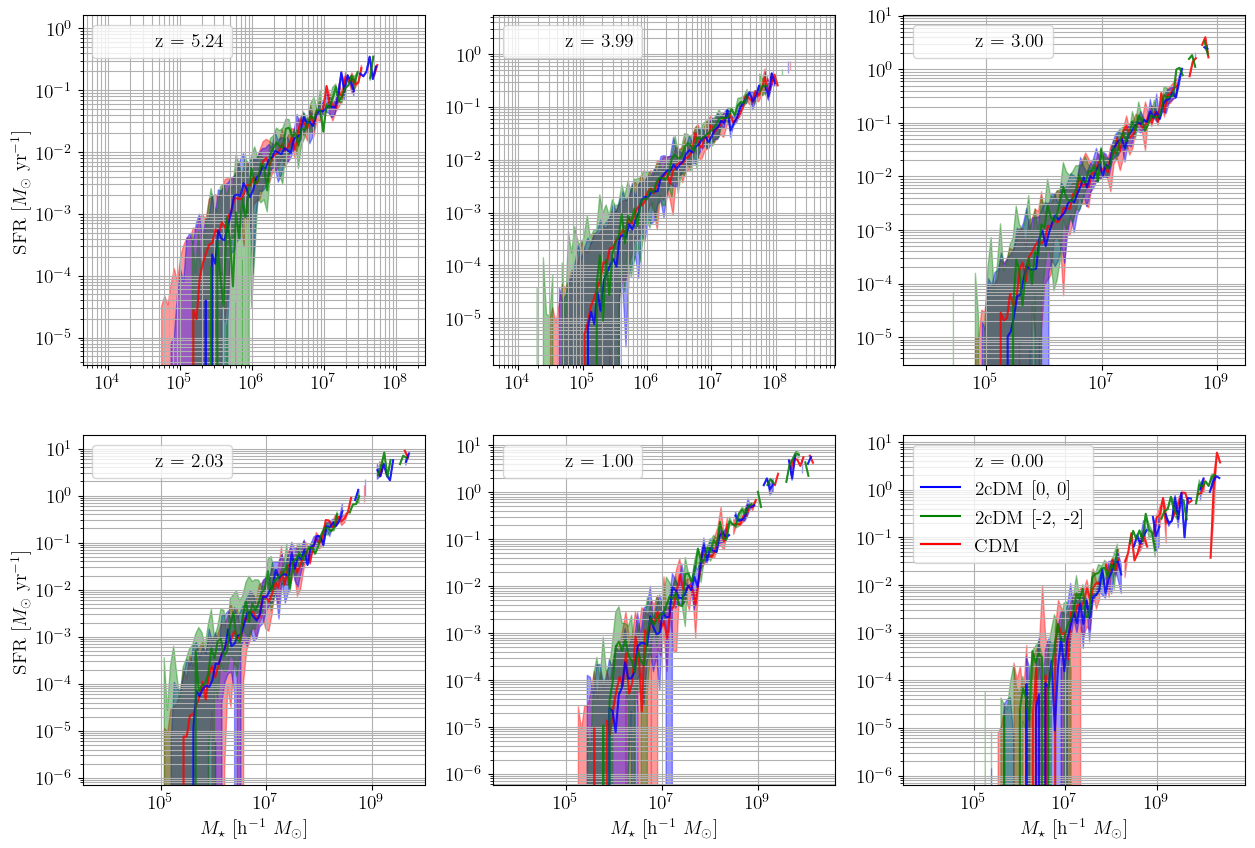

In [35]:
fig, ax = plt.subplots(2, 3, figsize=FIGSIZE)

for ar, snap_range in zip(ax, snap_ranges):
    for a, redshift in zip(ar, snap_range):

        cdm_m, cdm_med, cdm_10, cdm_90 = get_SFR_mass_stats(CDM_runs, redshift)

        tcdm_m, tcdm_med, tcdm_10, tcdm_90 = get_SFR_mass_stats(tcDM_runs1, redshift)

        twcdm_m, twcdm_med, twcdm_10, twcdm_90 = get_SFR_mass_stats(tcDM_runs2, redshift)

        a.plot(cdm_m, cdm_med, alpha=ALPHA, color=cdm_color)
        a.fill_between(cdm_m, cdm_10, cdm_90, alpha=0.5*ALPHA, color=cdm_color)

        a.plot(tcdm_m, tcdm_med, alpha=ALPHA, color=zz_color)
        a.fill_between(tcdm_m, tcdm_10, tcdm_90, alpha=0.5*ALPHA, color=zz_color)

        a.plot(twcdm_m, twcdm_med, alpha=ALPHA, color=m2m2_color)
        a.fill_between(twcdm_m, twcdm_10, twcdm_90, alpha=0.5*ALPHA, color=m2m2_color)

        r_nearest = cosmoSim(CDM_runs[0], base_path=base_path).get_nearest_redshift(redshift)


        a.set_yscale("log")
        a.set_xscale("log")
        # a.set_xlim(10**-2, 10**1)
        # a.set_ylim(10**-8, 10**1)
        a.grid(True, which="both", ls="-")
        a.set_aspect( 'auto', adjustable='box' )
        a.plot([],[], label=f'z = {r_nearest:.2f}', alpha=0)
        a.legend()


for ar in ax[1, :]:
    ar.set_xlabel('$M_{\\star}$ [h$^{-1}$ $M_{\\odot}$]')

for ar in ax[:, 0]: 
    ar.set_ylabel("SFR [$M_{\odot}$ yr$^{-1}$]")

a = ax[-1,-1]
a.plot([],[], label='2cDM [0, 0]', color=zz_color)
a.plot([],[], label='2cDM [-2, -2]', color=m2m2_color)
a.plot([],[], label='CDM', color=cdm_color)

a.legend()
fname = outpath + f'grid_SFR_mass.pdf'
plt.savefig(fname, dpi=DPI, bbox_inches='tight')
plt.show()

/home/ryan/projects/Medvedev/dm_sims/jupyter/global/paperI/../../../py/cosmoSim.py:118: UserWarning: WARNING: Requested redshift 5 is not within tolerance 0.1 of snapshot redshift 5.236226422509304 in run run_CDM_L3N256_HY_dir_0!
  warnings.warn(f"WARNING: Requested redshift {redshift} is not within tolerance {tolerance} of snapshot redshift {self.redshifts[idx]} in run {self.run_name}!")
/home/ryan/projects/Medvedev/dm_sims/jupyter/global/paperI/../../../py/cosmoSim.py:118: UserWarning: WARNING: Requested redshift 5 is not within tolerance 0.1 of snapshot redshift 5.236226422509304 in run run_CDM_L3N256_HY_dir_1!
  warnings.warn(f"WARNING: Requested redshift {redshift} is not within tolerance {tolerance} of snapshot redshift {self.redshifts[idx]} in run {self.run_name}!")
/home/ryan/projects/Medvedev/dm_sims/jupyter/global/paperI/../../../py/cosmoSim.py:118: UserWarning: WARNING: Requested redshift 5 is not within tolerance 0.1 of snapshot redshift 5.236226422509304 in run run_CDM_L3N

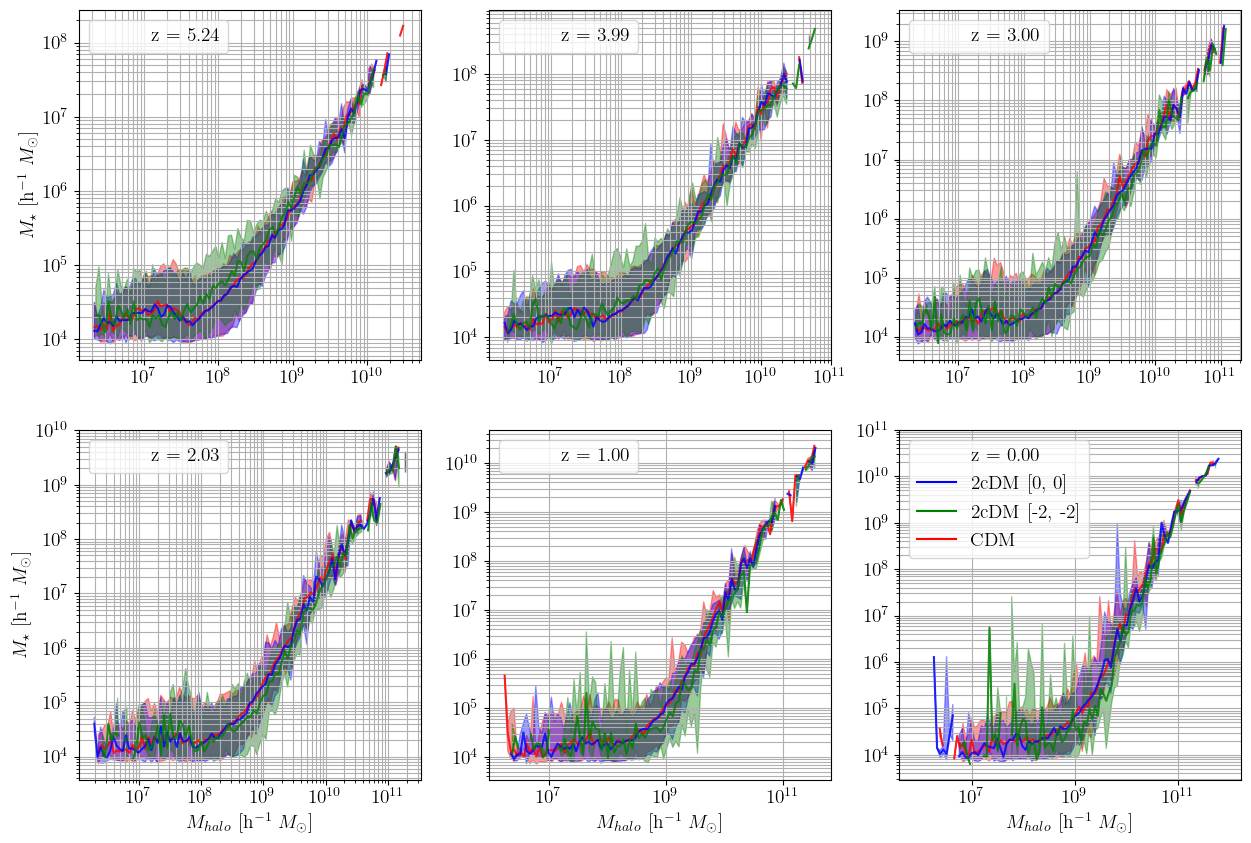

In [36]:
fig, ax = plt.subplots(2, 3, figsize=FIGSIZE)

for ar, snap_range in zip(ax, snap_ranges):
    for a, redshift in zip(ar, snap_range):

        cdm_m, cdm_med, cdm_10, cdm_90 = get_halo_stellar_mass_stats(CDM_runs, redshift)

        tcdm_m, tcdm_med, tcdm_10, tcdm_90 = get_halo_stellar_mass_stats(tcDM_runs1, redshift)

        twcdm_m, twcdm_med, twcdm_10, twcdm_90 = get_halo_stellar_mass_stats(tcDM_runs2, redshift)

        a.plot(cdm_m, cdm_med, alpha=ALPHA, color=cdm_color)
        a.fill_between(cdm_m, cdm_10, cdm_90, alpha=0.5*ALPHA, color=cdm_color)

        a.plot(tcdm_m, tcdm_med, alpha=ALPHA, color=zz_color)
        a.fill_between(tcdm_m, tcdm_10, tcdm_90, alpha=0.5*ALPHA, color=zz_color)

        a.plot(twcdm_m, twcdm_med, alpha=ALPHA, color=m2m2_color)
        a.fill_between(twcdm_m, twcdm_10, twcdm_90, alpha=0.5*ALPHA, color=m2m2_color)

        r_nearest = cosmoSim(CDM_runs[0], base_path=base_path).get_nearest_redshift(redshift)


        a.set_yscale("log")
        a.set_xscale("log")
        # a.set_xlim(10**-2, 10**1)
        # a.set_ylim(10**-8, 10**1)
        a.grid(True, which="both", ls="-")
        a.set_aspect( 'auto', adjustable='box' )
        a.plot([],[], label=f'z = {r_nearest:.2f}', alpha=0)
        a.legend()

for ar in ax[1, :]:
    ar.set_xlabel('$M_{halo}$ [h$^{-1}$ $M_{\\odot}$]')

for ar in ax[:, 0]: 
    ar.set_ylabel('$M_{\\star}$ [h$^{-1}$ $M_{\\odot}$]')

a = ax[-1,-1]
a.plot([],[], label='2cDM [0, 0]', color=zz_color)
a.plot([],[], label='2cDM [-2, -2]', color=m2m2_color)
a.plot([],[], label='CDM', color=cdm_color)

a.legend()
fname = outpath + f'grid_halomass_stellarmass.pdf'
plt.savefig(fname, dpi=DPI, bbox_inches='tight')
plt.show()